In [57]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'

from datetime import datetime, timedelta
from glob import glob

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import matplotlib
import matplotlib.patheffects as pe
import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, MultipleLocator
from scipy.ndimage import gaussian_filter

from zhiyi.plot.Plot_2D import Plot_2D



In [58]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
base_dir = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist"
file_template = "MUSICA_production3.2_BB.cam.h3.{date_str}-00000.nc"
date_list = [f"2018-06-{day:02d}" for day in range(25, 31)]

                                                                                      
FIG_SCALE = 1.35
FIGSIZE = (7.05 * FIG_SCALE, 7.18 * FIG_SCALE)
MAP_TICK_SIZE = 13.5
MAP_LABEL_SIZE = 7.0
MAP_PANEL_SIZE = 13
MAP_DATE_SIZE = 13
MAP_CITY_SIZE = 11
MAP_KEY_SIZE = 11
VERT_TICK_SIZE = 13.5
VERT_LABEL_SIZE = 14
VERT_PANEL_SIZE = 13
VERT_DATE_SIZE = 13
VERT_HEADER_SIZE = 13
VERT_LOCATION_SIZE = 10
CBAR_TICK_SIZE = 15
CBAR_LABEL_SIZE = 14
TEXTBOX_PAD = 0.25


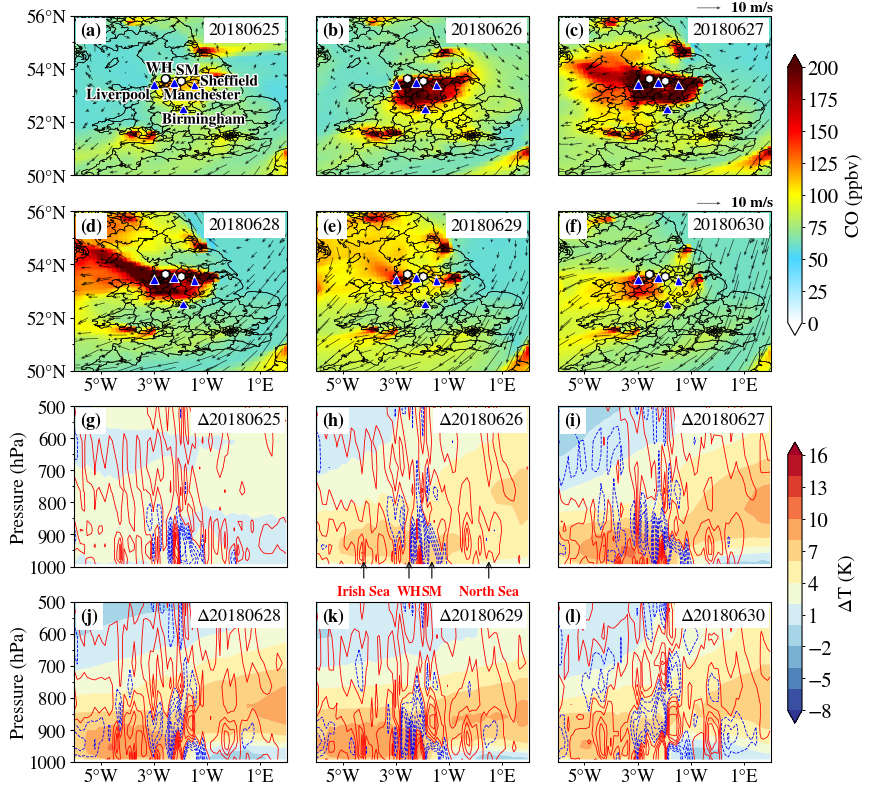

In [59]:
def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    if x > 0:
        return f"{x:.0f}°E"
    return f"{abs(x):.0f}°W"


def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    if y > 0:
        return f"{y:.0f}°N"
    return f"{abs(y):.0f}°S"


                                                                              
fig = plt.figure(figsize=FIGSIZE)
gs = GridSpec(
    4, 4,
    figure=fig,
    width_ratios=[1, 1, 1, 0.055],
    height_ratios=[1, 1, 1, 1],
    wspace=0.18,
    hspace=0.22,
)
map_axes = [fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree()) for r in range(2) for c in range(3)]
vertical_axes = [fig.add_subplot(gs[r, c]) for r in range(2, 4) for c in range(3)]
                                       
                                            
map_cax = fig.add_axes([0.875, 0.55, 0.015, 0.29])
vertical_cax = fig.add_axes([0.875, 0.15, 0.015, 0.29])

                                                                               
                                                                                               
file_paths_BB = [
    f"{base_dir}/{file_template.format(date_str=date_str)}"
    for date_str in date_list
]
datasets_BB = [xr.open_dataset(fp) for fp in file_paths_BB]

co_fields = []
for ds in datasets_BB:
                                                           
    co_ugm3 = ds["CO"].isel(time=0, lev=-1) * 1e9
    co_fields.append(co_ugm3)

plot_settings = []
for co_data in co_fields:
    title = ""
    vmin = 0
    vmax = 200
    unit = "ppbv"
    plot_settings.append((co_data, title, vmin, vmax, unit))

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]

                                             
lon_sm, lat_sm = -1.96000, 53.54200
lon_w, lat_w = -2.55667, 53.62944
lon_birmin, lat_birmin = -1.8904, 52.4862
lon_manchester, lat_manchester = -2.2426, 53.4808
lon_sheffield, lat_sheffield = -1.4701, 53.3811
lon_liverpool, lat_liverpool = -2.9916, 53.4084

step = 35
co_mappable = None
for i, (data, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = map_axes[i]
    ds = datasets_BB[i]

    p = Plot_2D(
        data, scrip_file=scrip_filename, pretty_tick=True,
        lon_range=[-6, 2],
        lat_range=[50, 56],
        lon_interval=2,
        lat_interval=2,
        resolution="10m",
        state=True, country=True, title=title, unit=unit,
        cmin=vmin, cmax=vmax,
        title_size=MAP_LABEL_SIZE,
        label_size=MAP_LABEL_SIZE,
        feature_line_lw=0.45,
        shrink=0.8,
        unit_offset=[0.05, 0],
        pad=0.14,
        grid_line=False,
        lonlat_line=False,
        colorbar=False,
        ax=ax,
    )
    co_mappable = p.im

    FIRE_MARKER_SIZE = 4
    CITY_MARKER_SIZE = 4

    wh_marker = 'o' if i == 0 else 'h'
    ax.plot(lon_sm, lat_sm, marker='h', markersize=FIRE_MARKER_SIZE, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree())
    ax.plot(lon_w, lat_w, marker=wh_marker, markersize=FIRE_MARKER_SIZE, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree())
    for lon_city, lat_city in [
        (lon_birmin, lat_birmin),
        (lon_liverpool, lat_liverpool),
        (lon_manchester, lat_manchester),
        (lon_sheffield, lat_sheffield),
    ]:
        ax.plot(lon_city, lat_city, marker='^', markersize=CITY_MARKER_SIZE, color='blue',
                path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
                transform=ccrs.PlateCarree())

    if i == 0:
        city_labels = [
            ("SM", lon_sm, lat_sm, lon_sm - 0.2, lat_sm + 0.24),
            ("WH", lon_w, lat_w, lon_w - 0.75, lat_w + 0.24),
            ("Manchester", lon_manchester, lat_manchester, lon_manchester - 0.4, lat_manchester - 0.62),
            ("Liverpool", lon_liverpool, lat_liverpool, lon_liverpool - 2.55, lat_liverpool - 0.54),
            ("Sheffield", lon_sheffield, lat_sheffield, lon_sheffield + 0.22, lat_sheffield),
            ("Birmingham", lon_birmin, lat_birmin, lon_birmin - 0.8, lat_birmin - 0.54),
        ]
        for label, lon_pt, lat_pt, lon_txt, lat_txt in city_labels:
            ax.annotate(
                label,
                xy=(lon_pt, lat_pt),
                xytext=(lon_txt, lat_txt),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                fontsize=11,
                weight='semibold',
                color='black',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            )

    if "time" in ds.dims:
        u_field = ds["U"].isel(time=0, lev=-1).values
        v_field = ds["V"].isel(time=0, lev=-1).values
    else:
        u_field = ds["U"].isel(lev=-1).values
        v_field = ds["V"].isel(lev=-1).values

    q = ax.quiver(
        lon_scrip[::step], lat_scrip[::step], u_field[::step], v_field[::step],
        scale=90, color='k', width=0.003, alpha=0.8,
        headaxislength=5, headwidth=5, headlength=6,
        transform=ccrs.PlateCarree(),
    )
    if i in [2, 5]:
        ax.quiverkey(
            q, X=0.765, Y=1.05, U=10, label='10 m/s',
            labelpos='E', coordinates='axes',
            fontproperties=FontProperties(size=11, weight='bold'),
        )

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    map_xticks = np.array([-5, -3, -1, 1])
    ax.set_xticks([], minor=False)
    ax.set_xticks(map_xticks, minor=True)
    ax.xaxis.set_minor_formatter(FuncFormatter(lon_formatter))
    if i in [0, 3]:
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.tick_params(axis='y', which='major', labelsize=MAP_TICK_SIZE, pad=2.5, length=3.2, width=0.8)
        ax.tick_params(axis='y', which='minor', length=1.8, width=0.7)
    else:
        ax.yaxis.set_tick_params(which='both', labelleft=False, labelright=False, left=False, right=False)
        ax.tick_params(axis='y', which='minor', left=False, right=False)

    ax.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='x', which='minor', labelsize=MAP_TICK_SIZE, pad=2.5, length=1.8, width=0.7, bottom=True, top=False, labelbottom=True)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

    day = 25 + i
    ax.text(0.972, 0.96, f"201806{day:02d}", transform=ax.transAxes,
            fontsize=MAP_DATE_SIZE, va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))
    ax.text(0.030, 0.96, f'({chr(ord("a") + i)})', transform=ax.transAxes,
            fontsize=MAP_PANEL_SIZE, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))

cb = fig.colorbar(
    co_mappable,
    cax=map_cax,
    orientation='vertical',
    extend='both',
    ticks=np.arange(0, 225, 25),
)
cb.ax.tick_params(labelsize=15, length=2.3, width=0.7, pad=1.5)
cb.set_label('CO (ppbv)', fontsize=14, labelpad=5)
cb.ax.yaxis.set_label_position('right')

                                                                               
                                                                                                      
lat0, dlat = 53.40, 0.25
lon_min, lon_max = -6, 2
n = 10

base_file = f"{base_dir}/MUSICA_production3.2_BB.cam.h3.2018-06-24-00000.nc"
ds_base = xr.open_dataset(base_file)
lat = ds_base['lat'].values
lon = ds_base['lon'].values
lev = ds_base['lev'].values

idx_lat = np.where(np.abs(lat - lat0) <= dlat)[0]
lon_ = lon.copy()
lon_[lon_ > 180] -= 360
idx_lon = np.where((lon_[idx_lat] >= lon_min) & (lon_[idx_lat] <= lon_max))[0]
idx_sel = idx_lat[idx_lon]
lon_sel = lon_[idx_sel]
sorter = np.argsort(lon_sel)
lon_sel = lon_sel[sorter]

vertical_mappable = None
for i, date_str in enumerate(date_list):
    file_nc = f"{base_dir}/MUSICA_production3.2_BB.cam.h3.{date_str}-00000.nc"
    ds_1 = xr.open_dataset(file_nc)

    T_1 = ds_1['T'][0, :, :].values
    T_0 = ds_base['T'][0, :, :].values
    T = T_1 - T_0

    OMEGA_1 = ds_1['OMEGA'][0, :, :].values
    OMEGA_0 = ds_base['OMEGA'][0, :, :].values
    OMEGA = (OMEGA_1 - OMEGA_0) * 100

    T_sel = T[:, idx_sel][:, sorter]
    OMEGA_sel = OMEGA[:, idx_sel][:, sorter]
    lon_sel_sparse = lon_sel[::n]
    T_sel_sparse = T_sel[:, ::n]
    OMEGA_sel_sparse = OMEGA_sel[:, ::n]
    OMEGA_sel_sparse = np.clip(OMEGA_sel_sparse, -60, 40)

    Lon, Lev = np.meshgrid(lon_sel_sparse, lev)
    ax = vertical_axes[i]

    T_smooth = gaussian_filter(T_sel_sparse, sigma=0.6, mode='nearest')
    temp_levels = np.arange(-8, 17, 2)
    cf = ax.contourf(
        Lon, Lev, T_smooth, levels=temp_levels,
        cmap='RdYlBu_r', extend='both',
        antialiased=True,
    )
    vertical_mappable = cf

    neg_levels = np.arange(-45, 0, 12)
    pos_levels = np.arange(0, 40, 12)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=neg_levels, colors='b', linestyles='dashed', linewidths=0.6)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=pos_levels, colors='r', linestyles='solid', linewidths=0.6)

    if i == 1:
        for label, loc, dx in [
            ('Irish Sea', -4.1, -0.1),
            ('WH', -2.5, 0.0),
            ('SM', -1.74, 0.1),
            ('North Sea', 0.5, 0.0),
        ]:
            marker_lon = loc + dx
            ax.annotate(
                '',
                xy=(marker_lon, 0.05),
                xycoords=('data', 'axes fraction'),
                xytext=(marker_lon, -0.09),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', color='k', linewidth=0.8),
            )
            ax.text(
                marker_lon, -0.12, label,
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=10,
                color='r', weight='bold',
            )

    xticks = np.array([-5, -3, -1, 1])
    ax.set_xticks([], minor=False)
    ax.set_xticks(xticks, minor=True)
    ax.xaxis.set_minor_formatter(FuncFormatter(lon_formatter))
    ax.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='x', which='minor', labelsize=VERT_TICK_SIZE, pad=2.5, length=1.8, width=0.7, bottom=True, top=False, labelbottom=True)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    if i in [1, 2, 4, 5]:
        ax.set_ylabel("", fontsize=VERT_LABEL_SIZE, labelpad=12)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=VERT_TICK_SIZE, pad=4, length=3.2, width=0.8,
                       labelleft=False, labelright=False, left=False, right=False)
        ax.tick_params(axis='y', which='minor', length=1.8, width=0.7,
                       labelleft=False, labelright=False, left=False, right=False)

    if i % 3 == 0:
        ax.set_ylabel('Pressure (hPa)', fontsize=14, labelpad=1)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=VERT_TICK_SIZE, pad=2.5, length=3.2, width=0.8)
        ax.tick_params(axis='y', which='minor', length=1.8, width=0.7)

    ax.invert_yaxis()
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(1000, 500)
    ax.set_yticks(np.arange(500, 1001, 100))

                                                                 
    ax.text(0.0, 1.01, '', fontsize=13, ha='left',
            va='bottom', transform=ax.transAxes)
    day = 25 + i
    ax.text(0.972, 0.962, f"Δ201806{day:02d}", transform=ax.transAxes,
            fontsize=VERT_DATE_SIZE, va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))
    ax.text(0.030, 0.962, f'({chr(ord("g") + i)})', transform=ax.transAxes,
            fontsize=VERT_PANEL_SIZE, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))

cbar = fig.colorbar(
    vertical_mappable,
    cax=vertical_cax,
    orientation='vertical',
    ticks=np.arange(-8, 18, 3),
    aspect=18,
    extend='both',
)
cbar.set_label('ΔT (K)', fontsize=14, labelpad=5)
cbar.ax.tick_params(labelsize=15, length=2.3, width=0.7, pad=1.5)


In [ ]:
figure_data_dir = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data"
figure8_nc = os.path.join(figure_data_dir, "Figure8.nc")
os.makedirs(figure_data_dir, exist_ok=True)

file_paths_BB = [
    f"{base_dir}/{file_template.format(date_str=date_str)}"
    for date_str in date_list
]
datasets_BB = [xr.open_dataset(fp) for fp in file_paths_BB]

co_1000 = []
u_1000 = []
v_1000 = []
for ds in datasets_BB:
    co_1000.append(ds["CO"].isel(time=0, lev=-1).values * 1e9)
    if "time" in ds.dims:
        u_1000.append(ds["U"].isel(time=0, lev=-1).values)
        v_1000.append(ds["V"].isel(time=0, lev=-1).values)
    else:
        u_1000.append(ds["U"].isel(lev=-1).values)
        v_1000.append(ds["V"].isel(lev=-1).values)

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]

lat0, dlat = 53.40, 0.25
lon_min, lon_max = -6, 2
n = 10
base_file = f"{base_dir}/MUSICA_production3.2_BB.cam.h3.2018-06-24-00000.nc"
ds_base = xr.open_dataset(base_file)
lat = ds_base['lat'].values
lon = ds_base['lon'].values
lev = ds_base['lev'].values

idx_lat = np.where(np.abs(lat - lat0) <= dlat)[0]
lon_ = lon.copy()
lon_[lon_ > 180] -= 360
idx_lon = np.where((lon_[idx_lat] >= lon_min) & (lon_[idx_lat] <= lon_max))[0]
idx_sel = idx_lat[idx_lon]
lon_sel = lon_[idx_sel]
sorter = np.argsort(lon_sel)
lon_sel = lon_sel[sorter]
lon_vertical = lon_sel[::n]

t_delta = []
omega_delta = []
for ds_1 in datasets_BB:
    T = ds_1['T'][0, :, :].values - ds_base['T'][0, :, :].values
    OMEGA = (ds_1['OMEGA'][0, :, :].values - ds_base['OMEGA'][0, :, :].values) * 100
    t_delta.append(T[:, idx_sel][:, sorter][:, ::n])
    omega_delta.append(np.clip(OMEGA[:, idx_sel][:, sorter][:, ::n], -60, 40))

figure8_data = xr.Dataset(
    data_vars={
        "co_1000": (("date", "ncol"), np.asarray(co_1000)),
        "u_1000": (("date", "ncol"), np.asarray(u_1000)),
        "v_1000": (("date", "ncol"), np.asarray(v_1000)),
        "lon_scrip": (("ncol",), np.asarray(lon_scrip)),
        "lat_scrip": (("ncol",), np.asarray(lat_scrip)),
        "t_delta": (("date", "lev", "lon_vertical"), np.asarray(t_delta)),
        "omega_delta": (("date", "lev", "lon_vertical"), np.asarray(omega_delta)),
    },
    coords={
        "date": date_list,
        "lev": lev,
        "lon_vertical": lon_vertical,
    },
)
figure8_data.to_netcdf(figure8_nc)
figure8_nc


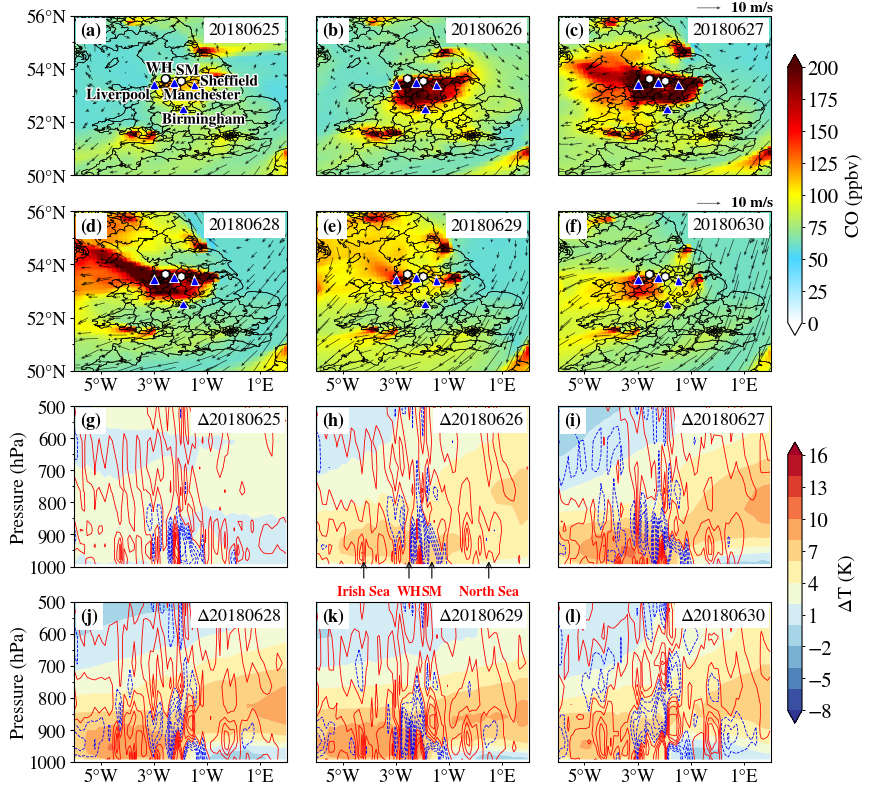

In [60]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
figure8_nc = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/Figure8.nc"
FIG_SCALE = 1.35
FIGSIZE = (7.05 * FIG_SCALE, 7.18 * FIG_SCALE)

MAP_TICK_SIZE=13.5
                                 
MAP_X_TICK_INTERVAL = 2
MAP_X_MINOR_TICK_INTERVAL = MAP_X_TICK_INTERVAL
MAP_X_MINOR_TICK_VALUES = [-5, -3, -1, 1]
MAP_Y_TICK_INTERVAL = 2
MAP_X_TICK_LABEL_SIZE = MAP_TICK_SIZE
MAP_Y_TICK_LABEL_SIZE = MAP_TICK_SIZE
MAP_X_MAJOR_TICK_LENGTH = 3.2
MAP_X_MINOR_TICK_LENGTH = 1.8
MAP_Y_MAJOR_TICK_LENGTH = 3.2
MAP_Y_MINOR_TICK_LENGTH = 1.8
MAP_X_MAJOR_TICK_WIDTH = 0.8
MAP_X_MINOR_TICK_WIDTH = 0.7
MAP_Y_MAJOR_TICK_WIDTH = 0.8
MAP_Y_MINOR_TICK_WIDTH = 0.7
MAP_X_TICK_PAD = 2.5
MAP_Y_TICK_PAD = 2.5

MAP_DATE_SIZE = 13
VERT_DATE_SIZE = 13
MAP_PANEL_SIZE = 13
VERT_PANEL_SIZE = 13


VERT_TICK_SIZE=13.5
                                 
VERT_X_TICK_INTERVAL = 2
VERT_X_MINOR_TICK_INTERVAL = VERT_X_TICK_INTERVAL
VERT_X_MINOR_TICK_VALUES = [-5, -3, -1, 1]
VERT_Y_TICK_INTERVAL = 100
VERT_X_TICK_LABEL_SIZE = VERT_TICK_SIZE
VERT_Y_TICK_LABEL_SIZE = VERT_TICK_SIZE
VERT_X_MAJOR_TICK_LENGTH = 3.2
VERT_X_MINOR_TICK_LENGTH = 1.8
VERT_Y_MAJOR_TICK_LENGTH = 3.2
VERT_Y_MINOR_TICK_LENGTH = 1.8
VERT_X_MAJOR_TICK_WIDTH = 0.8
VERT_X_MINOR_TICK_WIDTH = 0.7
VERT_Y_MAJOR_TICK_WIDTH = 0.8
VERT_Y_MINOR_TICK_WIDTH = 0.7
VERT_X_TICK_PAD = 2.5
VERT_Y_TICK_PAD = 2.5

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    if x > 0:
        return f"{x:.0f}°E"
    return f"{abs(x):.0f}°W"


def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    if y > 0:
        return f"{y:.0f}°N"
    return f"{abs(y):.0f}°S"


figure8_saved = xr.open_dataset(figure8_nc)
date_labels = pd.to_datetime(figure8_saved["date"].values).strftime("%Y%m%d")

fig = plt.figure(figsize=FIGSIZE)
gs = GridSpec(
    4, 4,
    figure=fig,
    width_ratios=[1, 1, 1, 0.055],
    height_ratios=[1, 1, 1, 1],
    wspace=0.18,
    hspace=0.22,
)
map_axes = [fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree()) for r in range(2) for c in range(3)]
vertical_axes = [fig.add_subplot(gs[r, c]) for r in range(2, 4) for c in range(3)]
                                       
                                            
map_cax = fig.add_axes([0.875, 0.55, 0.015, 0.29])
vertical_cax = fig.add_axes([0.875, 0.15, 0.015, 0.29])


lon_scrip = figure8_saved["lon_scrip"].values
lat_scrip = figure8_saved["lat_scrip"].values

lon_sm, lat_sm = -1.96000, 53.54200
lon_w, lat_w = -2.55667, 53.62944
lon_birmin, lat_birmin = -1.8904, 52.4862
lon_manchester, lat_manchester = -2.2426, 53.4808
lon_sheffield, lat_sheffield = -1.4701, 53.3811
lon_liverpool, lat_liverpool = -2.9916, 53.4084

step = 35
co_mappable = None
for i in range(len(date_labels)):
    ax = map_axes[i]
    data = figure8_saved["co_1000"].isel(date=i)

    p = Plot_2D(
        data, scrip_file=scrip_filename, pretty_tick=True,
        lon_range=[-6, 2],
        lat_range=[50, 56],
        lon_interval=MAP_X_TICK_INTERVAL,
        lat_interval=MAP_Y_TICK_INTERVAL,
        resolution="10m",
        state=True, country=True, title="", unit="ppbv",
        cmin=0, cmax=200,
        title_size=MAP_LABEL_SIZE,
        label_size=MAP_LABEL_SIZE,
        feature_line_lw=0.45,
        shrink=0.8,
        unit_offset=[0.05, 0],
        pad=0.14,
        grid_line=False,
        lonlat_line=False,
        colorbar=False,
        ax=ax,
    )
    co_mappable = p.im

    FIRE_MARKER_SIZE = 4
    CITY_MARKER_SIZE = 4

    wh_marker = 'o' if i == 0 else 'h'
    ax.plot(lon_sm, lat_sm, marker='h', markersize=FIRE_MARKER_SIZE, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree())
    ax.plot(lon_w, lat_w, marker=wh_marker, markersize=FIRE_MARKER_SIZE, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree())
    for lon_city, lat_city in [
        (lon_birmin, lat_birmin),
        (lon_liverpool, lat_liverpool),
        (lon_manchester, lat_manchester),
        (lon_sheffield, lat_sheffield),
    ]:
        ax.plot(lon_city, lat_city, marker='^', markersize=CITY_MARKER_SIZE, color='blue',
                path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
                transform=ccrs.PlateCarree())

    if i == 0:
        city_labels = [
            ("SM", lon_sm, lat_sm, lon_sm - 0.2, lat_sm + 0.24),
            ("WH", lon_w, lat_w, lon_w - 0.75, lat_w + 0.24),
            ("Manchester", lon_manchester, lat_manchester, lon_manchester - 0.4, lat_manchester - 0.62),
            ("Liverpool", lon_liverpool, lat_liverpool, lon_liverpool - 2.55, lat_liverpool - 0.54),
            ("Sheffield", lon_sheffield, lat_sheffield, lon_sheffield + 0.22, lat_sheffield),
            ("Birmingham", lon_birmin, lat_birmin, lon_birmin - 0.8, lat_birmin - 0.54),
        ]
        for label, lon_pt, lat_pt, lon_txt, lat_txt in city_labels:
            ax.annotate(
                label,
                xy=(lon_pt, lat_pt),
                xytext=(lon_txt, lat_txt),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                fontsize=11,
                weight='semibold',
                color='black',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            )

    q = ax.quiver(
        lon_scrip[::step], lat_scrip[::step],
        figure8_saved["u_1000"].isel(date=i).values[::step],
        figure8_saved["v_1000"].isel(date=i).values[::step],
        scale=90, color='k', width=0.003, alpha=0.8,
        headaxislength=5, headwidth=5, headlength=6,
        transform=ccrs.PlateCarree(),
    )
    if i in [2, 5]:
        ax.quiverkey(
            q, X=0.765, Y=1.05, U=10, label='10 m/s',
            labelpos='E', coordinates='axes',
            fontproperties=FontProperties(size=11, weight='bold'),
        )

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    map_xticks = np.asarray(MAP_X_MINOR_TICK_VALUES)
    ax.set_xticks([], minor=False)
    ax.set_xticks(map_xticks, minor=True)
    ax.xaxis.set_minor_formatter(FuncFormatter(lon_formatter))
    if i in [0, 3]:
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.tick_params(axis='y', which='major', labelsize=MAP_Y_TICK_LABEL_SIZE, pad=MAP_Y_TICK_PAD, length=MAP_Y_MAJOR_TICK_LENGTH, width=MAP_Y_MAJOR_TICK_WIDTH)
        ax.tick_params(axis='y', which='minor', length=MAP_Y_MINOR_TICK_LENGTH, width=MAP_Y_MINOR_TICK_WIDTH)
    else:
        ax.yaxis.set_tick_params(which='both', labelleft=False, labelright=False, left=False, right=False)
        ax.tick_params(axis='y', which='minor', left=False, right=False)

    ax.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='x', which='minor', labelsize=MAP_X_TICK_LABEL_SIZE, pad=MAP_X_TICK_PAD, length=MAP_X_MINOR_TICK_LENGTH, width=MAP_X_MINOR_TICK_WIDTH, bottom=True, top=False, labelbottom=True)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

    ax.text(0.972, 0.96, date_labels[i], transform=ax.transAxes,
            fontsize=MAP_DATE_SIZE, va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))
    ax.text(0.030, 0.96, f'({chr(ord("a") + i)})', transform=ax.transAxes,
            fontsize=MAP_PANEL_SIZE, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))

cb = fig.colorbar(
    co_mappable,
    cax=map_cax,
    orientation='vertical',
    extend='both',
    ticks=np.arange(0, 225, 25),
)
cb.ax.tick_params(labelsize=15, length=2.3, width=0.7, pad=1.5)
cb.set_label('CO (ppbv)', fontsize=14, labelpad=5)
cb.ax.yaxis.set_label_position('right')

lon_min, lon_max = -6, 2
lon_vertical = figure8_saved["lon_vertical"].values
lev = figure8_saved["lev"].values
Lon, Lev = np.meshgrid(lon_vertical, lev)
vertical_mappable = None
for i in range(len(date_labels)):
    ax = vertical_axes[i]
    T_smooth = gaussian_filter(figure8_saved["t_delta"].isel(date=i).values, sigma=0.6, mode='nearest')
    OMEGA_sel_sparse = figure8_saved["omega_delta"].isel(date=i).values

    temp_levels = np.arange(-8, 17, 2)
    cf = ax.contourf(
        Lon, Lev, T_smooth, levels=temp_levels,
        cmap='RdYlBu_r', extend='both',
        antialiased=True,
    )
    vertical_mappable = cf

    neg_levels = np.arange(-45, 0, 12)
    pos_levels = np.arange(0, 40, 12)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=neg_levels, colors='b', linestyles='dashed', linewidths=0.6)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=pos_levels, colors='r', linestyles='solid', linewidths=0.6)

    if i == 1:
        for label, loc, dx in [
            ('Irish Sea', -4.1, -0.1),
            ('WH', -2.5, 0.0),
            ('SM', -1.74, 0.1),
            ('North Sea', 0.5, 0.0),
        ]:
            marker_lon = loc + dx
            ax.annotate(
                '',
                xy=(marker_lon, 0.05),
                xycoords=('data', 'axes fraction'),
                xytext=(marker_lon, -0.09),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', color='k', linewidth=0.8),
            )
            ax.text(
                marker_lon, -0.12, label,
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=10,
                color='r', weight='bold',
            )

    xticks = np.asarray(VERT_X_MINOR_TICK_VALUES)
    ax.set_xticks([], minor=False)
    ax.set_xticks(xticks, minor=True)
    ax.xaxis.set_minor_formatter(FuncFormatter(lon_formatter))
    ax.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='x', which='minor', labelsize=VERT_X_TICK_LABEL_SIZE, pad=VERT_X_TICK_PAD, length=VERT_X_MINOR_TICK_LENGTH, width=VERT_X_MINOR_TICK_WIDTH, bottom=True, top=False, labelbottom=True)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    if i in [1, 2, 4, 5]:
        ax.set_ylabel("", fontsize=VERT_LABEL_SIZE, labelpad=12)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=VERT_Y_TICK_LABEL_SIZE, pad=VERT_Y_TICK_PAD, length=VERT_Y_MAJOR_TICK_LENGTH, width=VERT_Y_MAJOR_TICK_WIDTH,
                       labelleft=False, labelright=False, left=False, right=False)
        ax.tick_params(axis='y', which='minor', length=VERT_Y_MINOR_TICK_LENGTH, width=VERT_Y_MINOR_TICK_WIDTH,
                       labelleft=False, labelright=False, left=False, right=False)

    if i % 3 == 0:
        ax.set_ylabel('Pressure (hPa)', fontsize=14, labelpad=1)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=VERT_Y_TICK_LABEL_SIZE, pad=VERT_Y_TICK_PAD, length=VERT_Y_MAJOR_TICK_LENGTH, width=VERT_Y_MAJOR_TICK_WIDTH)
        ax.tick_params(axis='y', which='minor', length=VERT_Y_MINOR_TICK_LENGTH, width=VERT_Y_MINOR_TICK_WIDTH)

    ax.invert_yaxis()
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(1000, 500)
    ax.set_yticks(np.arange(500, 1001, VERT_Y_TICK_INTERVAL))

                                                                 
    ax.text(0.0, 1.01, '', fontsize=13, ha='left',
            va='bottom', transform=ax.transAxes)
    ax.text(0.972, 0.962, f"Δ{date_labels[i]}", transform=ax.transAxes,
            fontsize=VERT_DATE_SIZE, va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))
    ax.text(0.030, 0.962, f'({chr(ord("g") + i)})', transform=ax.transAxes,
            fontsize=VERT_PANEL_SIZE, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))

cbar = fig.colorbar(
    vertical_mappable,
    cax=vertical_cax,
    orientation='vertical',
    ticks=np.arange(-8, 18, 3),
    aspect=18,
    extend='both',
)
cbar.set_label('ΔT (K)', fontsize=14, labelpad=5)
cbar.ax.tick_params(labelsize=15, length=2.3, width=0.7, pad=1.5)
